> **AI-generated.** An AI assistant drafted this page, and no maintainer has reviewed it yet. Please report errors on the issue tracker.

# Tutorial 4: Forecasting with uncertainty

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TARPS-group/prob-pipe/blob/dev/overhaul/docs/tutorials/04_forecasting.ipynb)

[Tutorial 3](03_revising.ipynb) revised the model of the moose counts and fit it to the counts of 1967 to 1988.
In this tutorial we forecast the population of 1989 to 1993, compare harvests that a manager might set, and ask where the forecast's uncertainty comes from.

It develops three ideas of [how ProbPipe works](../index.md#how-it-works):

1. **Lifting:** an ordinary Python function applied to distributions returns the distribution of its output, and applied to a batch of inputs it returns a batch of results.
2. **Computation from capabilities:** a distribution can be held in more than one form, and `convert` changes the form when an operation needs another.
3. **Traceable, reproducible results:** every result records how it was computed, and a seed reproduces it.


In [1]:
# On Google Colab, install ProbPipe and download the data; elsewhere this cell does nothing.
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    import urllib.request

    %pip install --quiet "probpipe-core @ git+https://github.com/TARPS-group/prob-pipe.git@dev/overhaul"
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/TARPS-group/prob-pipe/dev/overhaul/"
        "docs/tutorials/data/moose.csv",
        "data/moose.csv",
    )

In [2]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from probpipe import (
    Beta,
    HalfNormal,
    KDEDistribution,
    LogNormal,
    Normal,
    NumericArrayBatch,
    Poisson,
    condition_on,
    conditional_distribution,
    convert,
    expectation,
    function,
    prob,
    quantile,
    variance,
    workflow_run,
)

# TensorFlow Probability warns that JAX runs in 32-bit precision, which these models use.
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype float64")

## 1. The model of tutorial 3

This cell repeats tutorial 3's model with process noise and fits it to the counts.
Sections 1 and 2 of tutorial 3 explain each part.

In [3]:
data = pd.read_csv("data/moose.csv")
years = data["year"].to_numpy()
counts = jnp.asarray(data["count"], dtype=jnp.float32)
YEARS = counts.shape[0]


def trajectory(r: jax.Array, K: jax.Array, n0: float, shocks: jax.Array) -> jax.Array:
    """The population in each year after the year of *n0*, given each year's shock to the growth."""

    def step(N: jax.Array, shock: jax.Array) -> tuple[jax.Array, jax.Array]:
        N_next = N * jnp.exp(r * (1.0 - N / K) + shock)
        return N_next, N_next

    _, N = jax.lax.scan(step, jnp.asarray(n0, dtype=jnp.float32), shocks)
    return N


prior = (
    LogNormal("K", jnp.log(350.0), 0.4)
    * LogNormal("r", jnp.log(0.4), 0.4)
    * Beta("phi", 2.0, 2.0)
    * HalfNormal("sigma", 0.2)
).with_label("prior")
def shocks_given_sigma(sigma: jax.Array) -> Normal:
    return Normal("shocks", jnp.zeros(YEARS), sigma)


prior_shocks = conditional_distribution(
    shocks_given_sigma, label="shocks", given_spec={"sigma": prior.event_spec.components["sigma"]}
)


def noisy_counts(
    K: jax.Array, r: jax.Array, phi: jax.Array, shocks: jax.Array, n0: float = 50.0
) -> Poisson:
    return Poisson("y", phi * trajectory(r, K, n0, shocks))


inputs = {name: prior.event_spec.components[name] for name in ["K", "r", "phi"]}
likelihood = conditional_distribution(
    noisy_counts,
    label="counts",
    given_spec={**inputs, "shocks": prior_shocks.event_spec.components["shocks"]},
)
model = (likelihood * prior_shocks * prior).with_label("model")
with workflow_run(seed=4):
    posterior = condition_on(model, {"y": counts})
DRAWS = posterior.num_atoms
print("posterior:", posterior)
print("number of draws:", DRAWS)

posterior: model(shocks, K, r, phi, sigma; y)
number of draws: 4000


## 2. The population as a function of the parameters

The population of each year is a function of the parameters and the shocks, which `trajectory` computes.
As in tutorial 2, `@function` makes it a ProbPipe function, which returns its value when called with numbers and the distribution of its value when called with distributions.

In [4]:
@function
def population(K: jax.Array, r: jax.Array, shocks: jax.Array) -> jax.Array:
    return trajectory(r, K, 50.0, shocks)


print("population in 1967 to 1971 with no shocks:", population(400.0, 0.3, jnp.zeros(YEARS))[:5])

population in 1967 to 1971 with no shocks: [ 65.00883  83.57684 105.96236 132.107   161.50432]


Called with the posterior's components, the function is evaluated at the posterior's draws.
The three arguments come from one distribution, so each evaluation reads them from the same draw, which keeps their dependence.
`with_options(n_broadcast_samples=DRAWS)` evaluates the function at as many draws as the posterior holds.

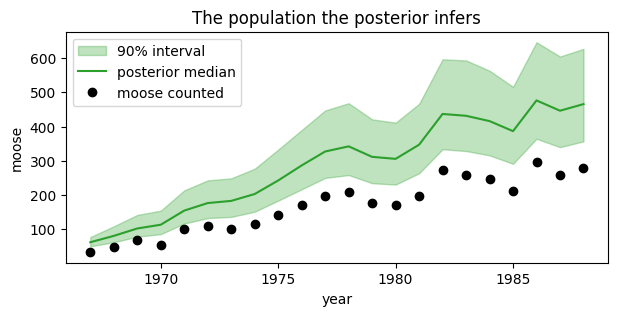

In [5]:
with workflow_run(seed=5):
    past_population = population.with_options(n_broadcast_samples=DRAWS)(
        posterior["K"], posterior["r"], posterior["shocks"]
    )
bands = quantile(past_population, jnp.array([0.05, 0.5, 0.95])).raw()

fig, ax = plt.subplots(figsize=(7, 3))
ax.fill_between(years, bands[0], bands[2], color="tab:green", alpha=0.3, label="90% interval")
ax.plot(years, bands[1], color="tab:green", label="posterior median")
ax.plot(years, counts, "o", color="black", label="moose counted")
ax.set(xlabel="year", ylabel="moose", title="The population the posterior infers")
ax.legend()
plt.show()

The population lies above the counts, since a survey finds each animal with probability $\phi$, whose posterior mean is near 0.6.

## 3. A forecast with new shocks

A forecast continues the recursion past 1988.
The parameters and the shocks of 1967 to 1988 come from the posterior, and the shocks of 1989 to 1993 are new: no count has informed them, so they follow their stage of the model, $\epsilon_t \sim \text{Normal}(0, \sigma)$.
Composing that stage with the posterior gives the joint distribution of the parameters, the past shocks, and the future shocks:

In [6]:
HORIZON = 5
future_years = np.arange(years[-1] + 1, years[-1] + 1 + HORIZON)
def future_shocks_given_sigma(sigma: jax.Array) -> Normal:
    return Normal("future_shocks", jnp.zeros(HORIZON), sigma)


prior_future_shocks = conditional_distribution(
    future_shocks_given_sigma,
    label="future_shocks",
    given_spec={"sigma": prior.event_spec.components["sigma"]},
)
forecast_joint = prior_future_shocks * posterior
print("components:", list(forecast_joint.event_spec.components))

components: ['future_shocks', 'shocks', 'K', 'r', 'phi', 'sigma']


`forecast_population` continues each trajectory with the future shocks.
Its last argument is an annual harvest, which defaults to none and which section 5 uses.

In [7]:
@function
def forecast_population(
    K: jax.Array, r: jax.Array, shocks: jax.Array, future_shocks: jax.Array, harvest: float = 0.0
) -> jax.Array:
    """The population of each future year, given the past and future shocks and an annual harvest."""

    def step(N: jax.Array, shock: jax.Array) -> tuple[jax.Array, jax.Array]:
        N_next = jnp.maximum(N * jnp.exp(r * (1.0 - N / K) + shock) - harvest, 0.0)
        return N_next, N_next

    _, future = jax.lax.scan(step, trajectory(r, K, 50.0, shocks)[-1], future_shocks)
    return future


with workflow_run(seed=6):
    forecast = forecast_population.with_options(n_broadcast_samples=DRAWS)(
        forecast_joint["K"], forecast_joint["r"], forecast_joint["shocks"], forecast_joint["future_shocks"]
    )
levels = jnp.array([0.05, 0.25, 0.5, 0.75, 0.95])
fan = quantile(forecast, levels).raw()
for year, low, median, high in zip(future_years, fan[0], fan[2], fan[4]):
    print(f"{year}: median {median:.0f} moose, 90% interval ({low:.0f}, {high:.0f})")

1989: median 453 moose, 90% interval (325, 640)
1990: median 443 moose, 90% interval (310, 646)
1991: median 437 moose, 90% interval (294, 651)
1992: median 436 moose, 90% interval (289, 651)
1993: median 432 moose, 90% interval (288, 645)


Each draw of the future shocks uses the same draw's $\sigma$, so the forecast keeps the dependence between the shocks and their scale.
The quantiles give a fan chart, whose band widens with the horizon:

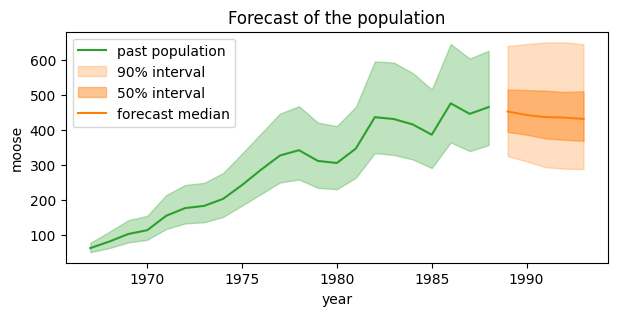

In [8]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.fill_between(years, bands[0], bands[2], color="tab:green", alpha=0.3)
ax.plot(years, bands[1], color="tab:green", label="past population")
ax.fill_between(future_years, fan[0], fan[4], color="tab:orange", alpha=0.25, label="90% interval")
ax.fill_between(future_years, fan[1], fan[3], color="tab:orange", alpha=0.45, label="50% interval")
ax.plot(future_years, fan[2], color="tab:orange", label="forecast median")
ax.set(xlabel="year", ylabel="moose", title="Forecast of the population")
ax.legend(loc="upper left")
plt.show()

## 4. The probability of an event

A manager may ask how likely an event is, such as the population falling below 300 animals in 1993.
The probability of an event is the expectation of its indicator, which `expectation` computes for a distribution and a function of its value.

In [9]:
def falls_below_300(N: jax.Array) -> jax.Array:
    """1 if the population of the last year, 1993, is below 300, and 0 otherwise."""
    return (N[-1] < 300.0).astype(jnp.float32)


below_300 = expectation(forecast, falls_below_300)
print("probability that the 1993 population is below 300:", round(float(below_300), 3))

probability that the 1993 population is below 300: 0.07


## 5. Harvest scenarios as a batch

A manager also sets a harvest, and each harvest gives a different forecast.
A **batch** holds several values of one kind, here three annual harvests, on a named axis called a **level**.
A function applied to a batch is applied to each of its values, so the forecast function applied to the posterior and the batch returns a batch of forecasts, one for each harvest:

In [10]:
harvests = NumericArrayBatch("harvest", jnp.array([0.0, 20.0, 40.0]), ("harvest",), axes_per_level=(1,))
with workflow_run(seed=7):
    scenario_forecasts = forecast_population.with_options(n_broadcast_samples=DRAWS)(
        forecast_joint["K"], forecast_joint["r"], forecast_joint["shocks"], forecast_joint["future_shocks"], harvests
    )
print("kind of result:", type(scenario_forecasts).__name__)
print("levels of the batch:", dict(zip(scenario_forecasts.level_names, scenario_forecasts.batch_shape)))

kind of result: DistributionBatch
levels of the batch: {'harvest': 3}


The operations apply to the batch as they did to one forecast, and each returns a batch of results:

harvest of 0 moose a year: probability below 300 in 1993 0.081
harvest of 20 moose a year: probability below 300 in 1993 0.244
harvest of 40 moose a year: probability below 300 in 1993 0.473


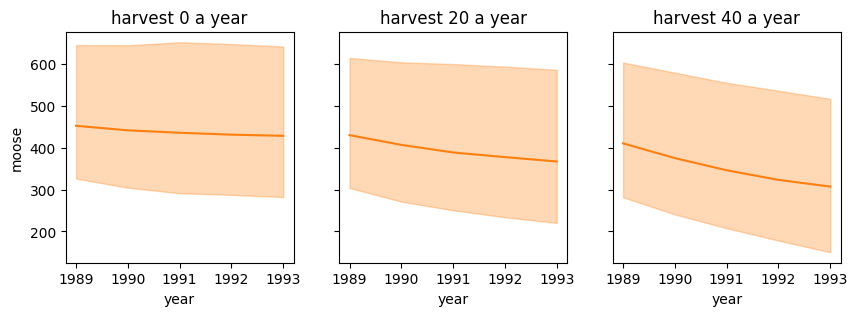

In [11]:
decline = expectation(scenario_forecasts, falls_below_300).raw()
for harvest, probability in zip(harvests.raw(), decline):
    print(f"harvest of {harvest:.0f} moose a year: probability below 300 in 1993 {probability:.3f}")


scenario_fans = quantile(scenario_forecasts, jnp.array([0.05, 0.5, 0.95])).raw()
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
for ax, harvest, scenario_fan in zip(axes, harvests.raw(), scenario_fans):
    ax.fill_between(future_years, scenario_fan[0], scenario_fan[2], color="tab:orange", alpha=0.3)
    ax.plot(future_years, scenario_fan[1], color="tab:orange")
    ax.set(title=f"harvest {harvest:.0f} a year", xlabel="year")
axes[0].set(ylabel="moose")
plt.show()

Each harvest of 20 animals a year raises the probability of falling below 300 by more than ten percentage points.
The probability with no harvest differs a little from section 4's, since each forecast is computed from its own draws, and the difference shrinks as the number of draws grows.

## 6. The density of the forecast

A plot of the forecast's density shows the event of section 4 as an area.
The forecast of 1993 is held as 4,000 draws, which have no density, but a distribution can be held in more than one form, and `convert` changes the form.
A **kernel density estimate** smooths draws into a continuous distribution, which has a density:

In [12]:
@function
def final_year(future: jax.Array) -> jax.Array:
    return future[-1]


with workflow_run(seed=8):
    forecast_1993 = final_year.with_options(n_broadcast_samples=DRAWS)(forecast)
density_1993 = convert(forecast_1993, KDEDistribution)
print("kind of the converted forecast:", type(density_1993).__name__)

kind of the converted forecast: KDEDistribution


`prob` evaluates a density at a value, and applied to a batch of values it returns a batch of densities, as the forecast function did for the harvests:

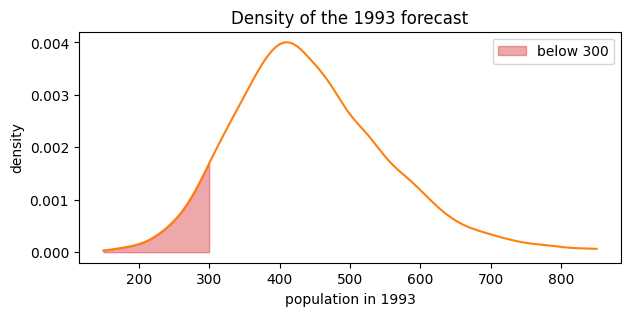

In [13]:
populations = NumericArrayBatch("population", jnp.linspace(150.0, 850.0, 141), ("grid",), axes_per_level=(1,))
heights = prob(density_1993, populations).raw()
grid = populations.raw()

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(grid, heights, color="tab:orange")
ax.fill_between(grid, heights, where=grid <= 300.0, color="tab:red", alpha=0.4, label="below 300")
ax.set(xlabel="population in 1993", ylabel="density", title="Density of the 1993 forecast")
ax.legend()
plt.show()

The shaded area is the probability of section 4.

## 7. Where the uncertainty comes from

The forecast is uncertain for two reasons: the parameters and the past shocks are uncertain, and the future shocks are random.
Fixing the future shocks at zero removes the second reason, so the variance of that forecast approximates the part due to the posterior, and the rest of the total variance approximates the part due to the future shocks.
The split guides what to do next: more counts narrow the first part, and nothing narrows the second.

1989: share of the forecast's variance due to the posterior 0.60
1990: share of the forecast's variance due to the posterior 0.54
1991: share of the forecast's variance due to the posterior 0.49
1992: share of the forecast's variance due to the posterior 0.49
1993: share of the forecast's variance due to the posterior 0.51


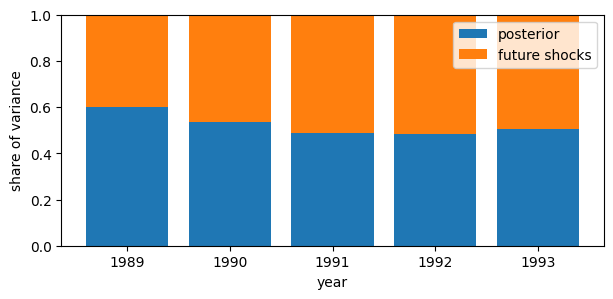

In [14]:
with workflow_run(seed=9):
    posterior_only_forecast = forecast_population.with_options(n_broadcast_samples=DRAWS)(
        posterior["K"], posterior["r"], posterior["shocks"], jnp.zeros(HORIZON)
    )
share = variance(posterior_only_forecast).raw() / variance(forecast).raw()
for year, fraction in zip(future_years, share):
    print(f"{year}: share of the forecast's variance due to the posterior {fraction:.2f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(future_years, share, color="tab:blue", label="posterior")
ax.bar(future_years, 1.0 - share, bottom=share, color="tab:orange", label="future shocks")
ax.set(xlabel="year", ylabel="share of variance", ylim=(0, 1))
ax.legend()
plt.show()

The posterior's share falls over the first years, as each year adds a new shock, and it levels off near one half, since the population returns toward its carrying capacity.

## 8. How each result was computed

Every ProbPipe result records how it was computed in its **provenance**: the operation, its inputs, the route it took, and whether that route is exact.
The results of this tutorial record these steps:

In [15]:
for name, result in [
    ("posterior", posterior),
    ("forecast", forecast),
    ("probability below 300", below_300),
    ("density of the 1993 forecast", density_1993),
]:
    record = result.provenance.metadata
    method = f", method {record['method']}" if "method" in record else ""
    print(f"{name}: route {record['route']}{method}, exact {record['exact']}")

posterior: route inference_methods, method blackjax_nuts, exact False
forecast: route sampling_lift, exact False
probability below 300: route closed_form, exact True
density of the 1993 forecast: route converters, method kde, exact False


Three steps are approximate: NUTS drew the posterior, the route `sampling_lift` evaluated the forecast function at draws of its arguments, and the conversion smoothed the draws into a density.
The probability is exact for the forecast's draws, so its error is the error of the first two steps, which more draws reduce.
The draws of each step come from the seed of its `workflow_run`, so running a step again with the same seed reproduces its result, as exercise 3 confirms.

## Exercises

Each exercise is followed by a solution, which Colab shows collapsed.

**Exercise 1.** Forecast the ten years to 1998 under each of the three harvests, and report the median and the 90% interval of the population of 1998.

In [16]:
# @title Solution
def ten_year_shocks_given_sigma(sigma: jax.Array) -> Normal:
    return Normal("future_shocks", jnp.zeros(10), sigma)


prior_ten_year_shocks = conditional_distribution(
    ten_year_shocks_given_sigma,
    label="future_shocks",
    given_spec={"sigma": prior.event_spec.components["sigma"]},
)
ten_year_joint = prior_ten_year_shocks * posterior
with workflow_run(seed=10):
    long_scenario_forecasts = forecast_population.with_options(n_broadcast_samples=DRAWS)(
        ten_year_joint["K"], ten_year_joint["r"], ten_year_joint["shocks"], ten_year_joint["future_shocks"], harvests
    )
long_fans = quantile(long_scenario_forecasts, jnp.array([0.05, 0.5, 0.95])).raw()
for harvest, long_fan in zip(harvests.raw(), long_fans):
    low, median, high = long_fan[:, -1]
    print(f"harvest {harvest:.0f}: 1998 median {median:.0f} moose, 90% interval ({low:.0f}, {high:.0f})")

harvest 0: 1998 median 425 moose, 90% interval (272, 652)
harvest 20: 1998 median 345 moose, 90% interval (186, 582)
harvest 40: 1998 median 240 moose, 90% interval (29, 485)


**Exercise 2.** Among the harvests 0, 10, 20, 30, and 40 animals a year, find the largest whose probability of a 1993 population below 200 stays under 10%.

In [17]:
# @title Solution
five_harvests = NumericArrayBatch(
    "harvest", jnp.array([0.0, 10.0, 20.0, 30.0, 40.0]), ("harvest",), axes_per_level=(1,)
)
with workflow_run(seed=11):
    five_scenario_forecasts = forecast_population.with_options(n_broadcast_samples=DRAWS)(
        forecast_joint["K"], forecast_joint["r"], forecast_joint["shocks"], forecast_joint["future_shocks"], five_harvests
    )
def falls_below_200(N: jax.Array) -> jax.Array:
    return (N[-1] < 200.0).astype(jnp.float32)


probability_below_200 = expectation(five_scenario_forecasts, falls_below_200).raw()
for harvest, probability in zip(five_harvests.raw(), probability_below_200):
    print(f"harvest {harvest:.0f}: probability below 200 in 1993 {probability:.3f}")
safe = [float(h) for h, p in zip(five_harvests.raw(), probability_below_200) if p < 0.1]
print("largest harvest under 10%:", max(safe))

harvest 0: probability below 200 in 1993 0.003
harvest 10: probability below 200 in 1993 0.010
harvest 20: probability below 200 in 1993 0.025
harvest 30: probability below 200 in 1993 0.065
harvest 40: probability below 200 in 1993 0.142
largest harvest under 10%: 30.0


**Exercise 3.** Compute the forecast of section 3 again with the seed it used, and confirm that the result is the same.

In [18]:
# @title Solution
with workflow_run(seed=6):
    forecast_again = forecast_population.with_options(n_broadcast_samples=DRAWS)(
        forecast_joint["K"], forecast_joint["r"], forecast_joint["shocks"], forecast_joint["future_shocks"]
    )
print("same quantiles:", bool(jnp.allclose(quantile(forecast_again, levels).raw(), fan)))

same quantiles: True


## Summary

- A Python function applied to the posterior returns the distribution of its value, and arguments from one distribution keep their dependence.
- The future shocks are a stage of the model, composed with the posterior, and the forecast is a function of that joint distribution.
- A batch holds several inputs, such as harvests, and the same function and operations applied to it return a batch of forecasts and of probabilities.
- `convert` changes the form of a distribution, here from draws to a kernel density estimate with a density, and records that the change is approximate.
- Each result's provenance says how it was computed and whether each step is exact, and a seed reproduces it.

[Tutorial 5](05_updating.ipynb) updates the forecasts as each year's count arrives.

## References

- Dietze, M. C. (2017). *Ecological Forecasting*. Princeton University Press. It partitions a forecast's uncertainty into its sources.